In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from emely import curve_fit

In [9]:
# define plot style
blue = "#648fff"
yellow = "#ffb000"
red = "#dc267f"
black = "#000000"

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.dpi"] = 300

In [10]:
# initialize the random number generator
rng = np.random.default_rng(42)

In [11]:
# define the model
def gaussian(x, a, mu, sigma):
    return a / np.sqrt(2 * np.pi * sigma**2) * np.exp(-((x - mu) ** 2) / (2 * sigma**2))

In [12]:
# create the Gaussian data with Poisson noise
p = (100, 5, 1)
x_data = np.linspace(0, 10, 51)
y_data = poisson.rvs(gaussian(x_data, *p), random_state=rng)

In [ ]:
# fit using MLE for Poisson noise
p0 = (50, 10, 5)
p_opt, p_cov = curve_fit(
    gaussian,
    x_data,
    y_data,
    p0=p0,
    noise="poisson",
)

# print results
p_err = np.sqrt(np.diag(p_cov))
for name, val, err in zip(["a", "μ", "σ"], p_opt, p_err):
    print(f"{name} = {val:.4g} +/- {err:.2g}")

a = 98.2 +/- 4.4
μ = 4.989 +/- 0.044
σ = 0.9793 +/- 0.031


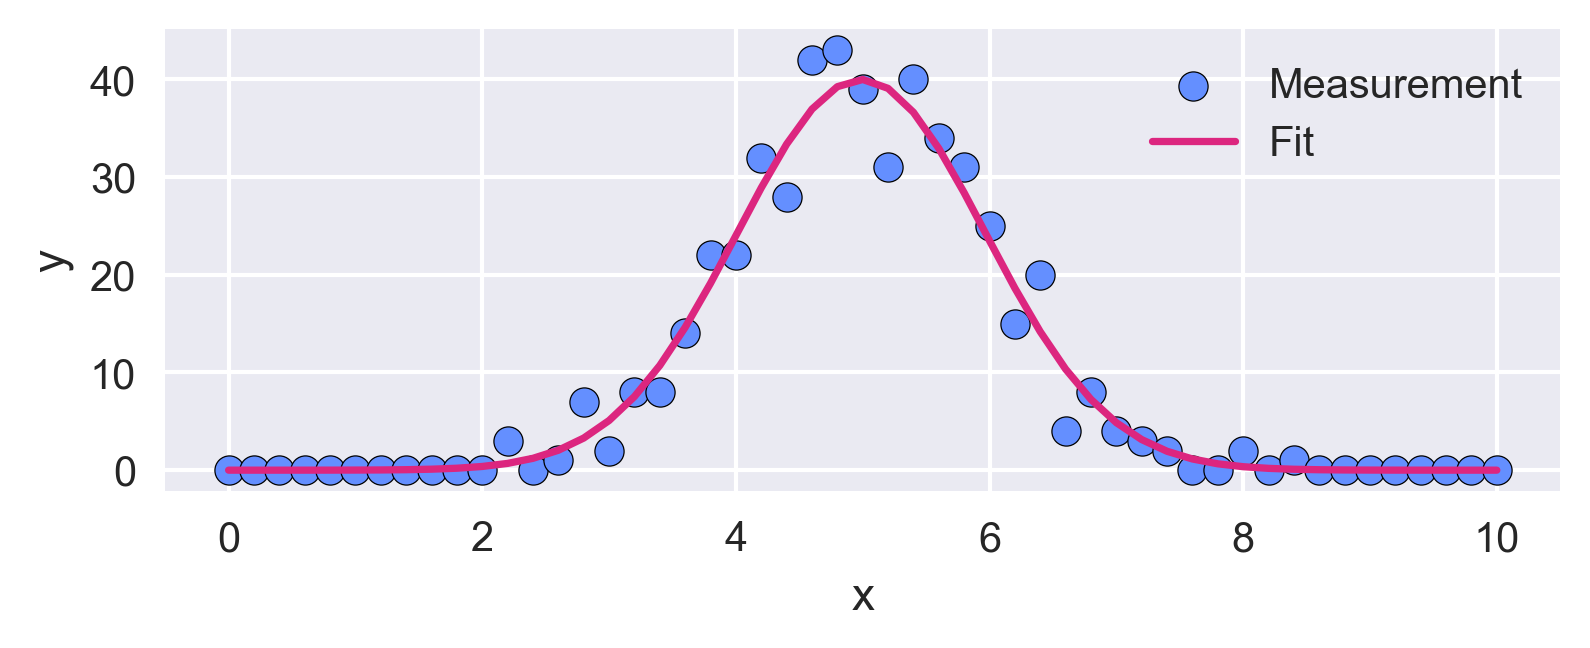

In [14]:
# show the fit
plt.figure(figsize=(6, 2))

plt.scatter(x_data, y_data, label="Measurement", edgecolor=black, facecolor=blue)
plt.plot(x_data, gaussian(x_data, *p_opt), label="Fit", color=red)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()